Data (X, y)
   ↓ preprocess_y
SurrogateTrainer.fit
   ↓
Grid (compute_bounds → create_nd_grid → filter_grid)
   ↓
trainer.predict → mean
pairwise_distances → std
   ↓
compute_acquisition (PI/EI/UCB, xi/kappa)
   ↓
argmax → next_query, score
   ↓
log_query_candidate
   ↓
find_best_candidate → best

![image.png](attachment:image.png)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

       floor     sugar      eggs    butter      milk  flavour-score  source
20  0.733334  0.200000  0.666667  0.733334  0.133334      -0.537794  week-1
22  0.667597  0.157201  0.738339  0.678368  0.179636      -0.683325  week-3
21  0.757576  0.101010  0.707071  0.757576  0.151515      -0.710242  week-2
0   0.728186  0.154693  0.732552  0.693997  0.056401      -0.714265    file
4   0.618812  0.331802  0.187288  0.756238  0.328835      -0.829237    file
17  0.782880  0.536336  0.443284  0.859700  0.010326      -0.935757    file
10  0.536797  0.308781  0.411879  0.388225  0.522528      -1.144785    file
1   0.242384  0.844100  0.577809  0.679021  0.501953      -1.209955    file
6   0.145111  0.896685  0.896322  0.726272  0.236272      -1.233786    file
5   0.784958  0.910682  0.708120  0.959225  0.004911      -1.247049    file
16  0.432166  0.715618  0.341819  0.705000  0.614962      -1.294247    file
9   0.757594  0.355831  0.016523  0.434207  0.112433      -1.309116    file
13  0.021735

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_43330/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


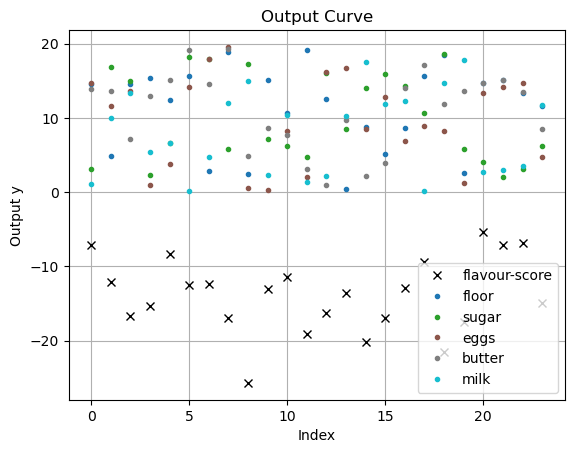

In [11]:
#Process data
%run data_handler.ipynb

In [12]:
#row_lowest_A = df_sorted.loc[df["radiation-reading"].idxmin()]
#print(row_lowest_A)
#df_sorted.drop(df["radiation-reading"].idxmin(), inplace=True)
# Preview
#print(df_sorted)
#plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=1000, nan_marker='o')


In [13]:
X = inputs
y = outputs

In [14]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []


In [15]:
def sweep_hyperparameters_NNtrain(X, y,
                                  xi_values=[0.01, 0.1, 0.3],
                                  kappa_values=[1.0, 2.0, 3.0],
                                  grid_sizes=[100],
                                  methods=['PI', 'EI', 'UCB'],
                                  apply_scaling=False,
                                  filter_mode='gp'):
    """
    Sweep hyperparameters for query selection using a trained NN surrogate.
    Applies Bayesian optimisation acquisition functions (PI, EI, UCB).
    """
    global query_results
    query_results = []

    # Step 1: preprocess targets
    y_proc = preprocess_y(y, apply_scaling=apply_scaling)

    # Step 2: train NN surrogate once
    trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)
    print("Epoch ", trainer.epochs)
    history = trainer.fit(X, y_proc, log_weights=True)
    # Plot loss curve
    plot_loss_curve(history)

    # Plot weight evolution (first layer mean)
    plot_weight_evolution(history, layer_name="model.0.weight", stat="mean")

    # Step 3: loop over grid sizes
    for grid_size in grid_sizes:
        bounds = compute_bounds(X, margin=0.1)
        X_grid_full = create_nd_grid(bounds, grid_size, downsample=True, stride=len(bounds))
        X_grid_filtered = filter_grid(X, y_proc, X_grid_full, filter_mode=filter_mode)

        if X_grid_filtered.shape[0] == 0:
            print(f"⚠️ Skipping grid_size={grid_size}, filter removed all points")
            continue

        # Step 4: predict surrogate outputs once per grid
        mean = trainer.predict(X_grid_filtered)

        # Step 5: uncertainty heuristic (distance to nearest training point)
        dist = pairwise_distances(X_grid_filtered, X)
        std = np.min(dist, axis=1)

        # Step 6: sweep acquisition hyperparameters
        for method in methods:
            if method in ['PI', 'EI']:
                for xi in xi_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, xi=xi)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, xi, next_query, score)

            elif method == 'UCB':
                for kappa in kappa_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, kappa=kappa)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, kappa, next_query, score)

    if not query_results:
        raise RuntimeError("No valid configurations found during sweep.")

    best = find_best_candidate(query_results)
    return X_grid_filtered, mean, bounds, best, query_results

Applying standard scaling to y.
Epoch  500
Epoch 1/500, Train Loss: 0.858317, Val Loss: 2.254462
Epoch 50/500, Train Loss: 0.089723, Val Loss: 0.224146
Epoch 100/500, Train Loss: 0.015800, Val Loss: 0.118682
Early stopping at epoch 136, best val_loss=0.108159


/Users/ajay.amrite/Library/CloudStorage/GoogleDrive-ajay.falcon.ai@gmail.com/My Drive/Capstone/Black-Box functions/utils/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


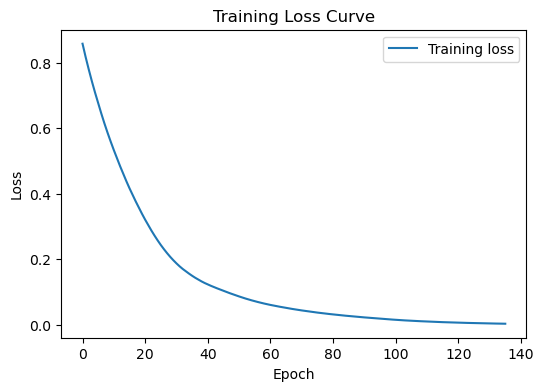

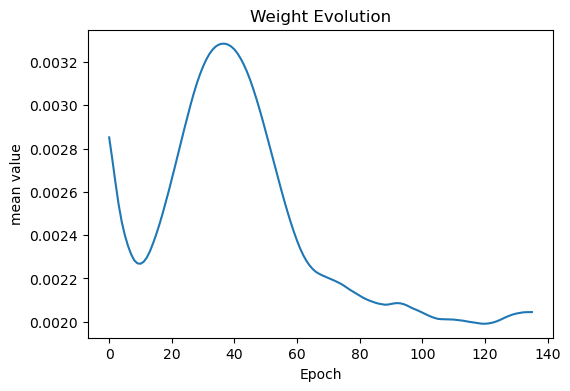

Computing bounds with margin 0.1.
Bounds per feature: [(-0.07826469233620362, 1.057739668883361), (0.001009999999999997, 1.0318712161635006), (-0.08347710031443636, 1.0788057635601997), (-0.05438681422055039, 1.0616555869902995), (-0.09508850413559536, 0.992819191058788)]
Using 5 dimensions.
Points before downsampling: 10000000000
Points after downsampling: 3200000
Final grid shape: (3200000, 5)
Filtering grid using mode: gp
Grid shape before filtering: (3200000, 5)


In [ ]:
X_grid_filtered, mean, bounds, best, query_results = sweep_hyperparameters_NNtrain(X, y, apply_scaling=True, filter_mode='gp')

In [ ]:
candidates, labels = extract_candidates_and_labels(query_results, include_score=True)

plot_surrogate_generic(X_grid_filtered, mean,
                       X_filtered=X_grid_filtered, bounds=bounds, candidates=candidates, candidate_labels=None,
                       title="Surrogate predictions with filtered points")


In [ ]:
print("Best Hyperparameter Configuration:")
print(best)

In [ ]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

In [ ]:
plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=100.0, nan_marker='o')